## Confusion matrix og saliency maps


Own CNN  test accuracy: 81.55%  (172 fejl af 932)


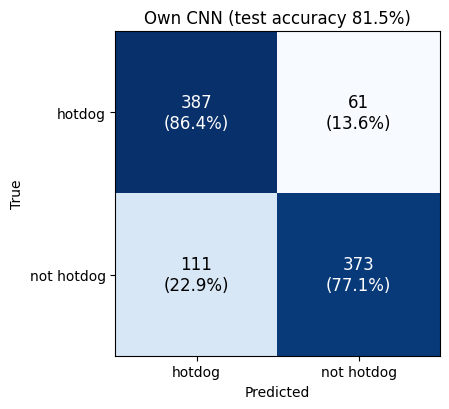

In [ ]:
CLASS_NAMES = ['hotdog', 'not hotdog']
test_paths = [full_testset.image_paths[i] for i in test_idx]


@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    probs, labs = [], []
    for x, y in loader:
        probs.append(torch.sigmoid(model(x.to(device))).view(-1).cpu())
        labs.append(y)
    return torch.cat(probs), torch.cat(labs)


def test_and_confusion(model, name, filename):
    probs, labs = predict_all(model, test_loader)
    preds = (probs > 0.5).long()
    acc = (preds == labs).float().mean().item()
    cm = np.zeros((2, 2), dtype=int)             
    for t, p in zip(labs.tolist(), preds.tolist()):
        cm[t, p] += 1
    print(f'{name}  test accuracy: {acc * 100:.2f}%  ({(preds != labs).sum().item()} fejl af {len(labs)})')

    fig, ax = plt.subplots(figsize=(5, 4.2))
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]}\n({cm[i, j] / cm[i].sum():.1%})', ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=12)
    ax.set_xticks([0, 1]); ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticks([0, 1]); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} (test accuracy {acc:.1%})')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    return dict(probs=probs, labels=labs, preds=preds, acc=acc, cm=cm)


cnn_model = model         
cnn_results = test_and_confusion(cnn_model, 'Own CNN', 'confusion_cnn.png')

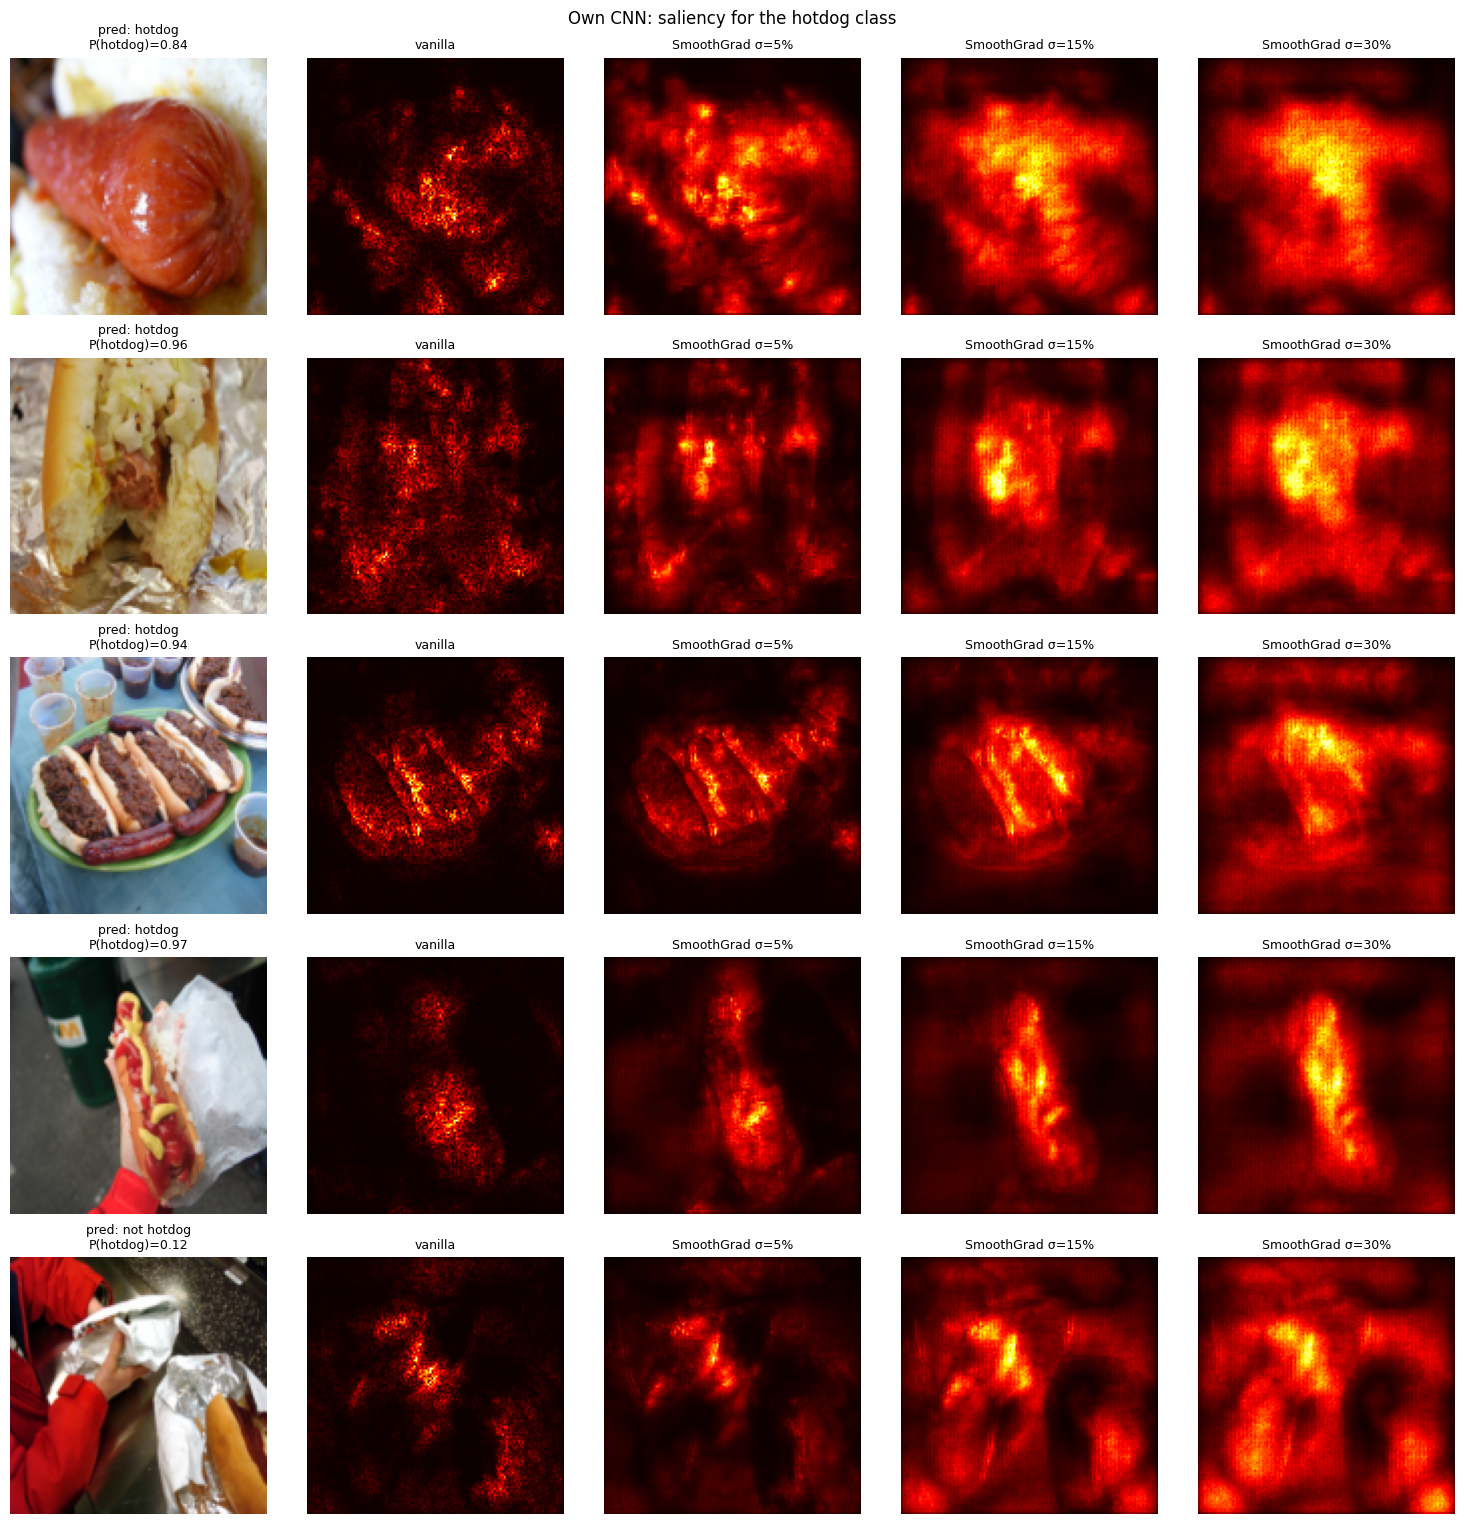

In [ ]:

SIGMAS = [0.05, 0.15, 0.30]     
N_SAMPLES = 50


def vanilla_saliency(model, x):
    # x: (1,3,H,W). Gradient af hotdog-scoren (-logit) mht. input, max over farvekanaler
    model.eval()
    x = x.clone().to(device).requires_grad_(True)
    score = (-model(x)).sum()
    grad, = torch.autograd.grad(score, x)
    return grad.abs().amax(dim=1).squeeze(0).cpu()


def smoothgrad(model, x, sigma_frac=0.15, n_samples=N_SAMPLES, chunk=10):
    model.eval()
    gen = torch.Generator().manual_seed(0)
    sigma = sigma_frac * (x.max() - x.min()).item()
    total, done = torch.zeros(x.shape[-2:]), 0
    while done < n_samples:
        b = min(chunk, n_samples - done)
        noisy = x.repeat(b, 1, 1, 1) + sigma * torch.randn(b, *x.shape[1:], generator=gen)
        noisy = noisy.to(device).requires_grad_(True)
        score = (-model(noisy)).sum()
        grad, = torch.autograd.grad(score, noisy)
        total += grad.abs().amax(dim=1).sum(0).cpu()
        done += b
    return total / n_samples


def saliency_grid(model, results, name, filename):
    n_cols = 2 + len(SIGMAS)
    plt.figure(figsize=(3 * n_cols, 3.1 * len(chosen)))
    for row, i in enumerate(chosen):
        x = testset[i][0].unsqueeze(0)
        maps = [vanilla_saliency(model, x)] + [smoothgrad(model, x, sigma_frac=s) for s in SIGMAS]
        titles = ['vanilla'] + [f'SmoothGrad σ={s:.0%}' for s in SIGMAS]
        plt.subplot(len(chosen), n_cols, row * n_cols + 1)
        plt.imshow(x[0].permute(1, 2, 0).numpy())
        plt.title(f"pred: {CLASS_NAMES[results['preds'][i]]}\nP(hotdog)={1 - results['probs'][i]:.2f}", fontsize=9)
        plt.axis('off')
        for c, (m, t) in enumerate(zip(maps, titles)):
            plt.subplot(len(chosen), n_cols, row * n_cols + 2 + c)
            plt.imshow((m / (m.max() + 1e-12)).numpy(), cmap='hot')
            plt.title(t, fontsize=9)
            plt.axis('off')
    plt.suptitle(f'{name}: saliency for the hotdog class')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()



is_hot = cnn_results['labels'] == 0
right = (is_hot & (cnn_results['preds'] == 0)).nonzero().view(-1)
wrong = (is_hot & (cnn_results['preds'] == 1)).nonzero().view(-1)
g = torch.Generator().manual_seed(0)
chosen = right[torch.randperm(len(right), generator=g)[:4]].tolist() + \
         wrong[torch.randperm(len(wrong), generator=g)[:1]].tolist()

saliency_grid(cnn_model, cnn_results, 'Own CNN', 'saliency_cnn.png')

### Test af ResNet18
Samme testsæt og samme billeder til saliency maps som for egen CNN.

ResNet18  test accuracy: 91.52%  (79 fejl af 932)


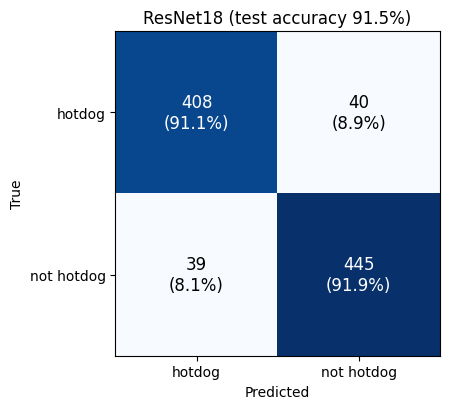

In [15]:
resnet_model = model
resnet_results = test_and_confusion(resnet_model, 'ResNet18', 'confusion_resnet18.png')

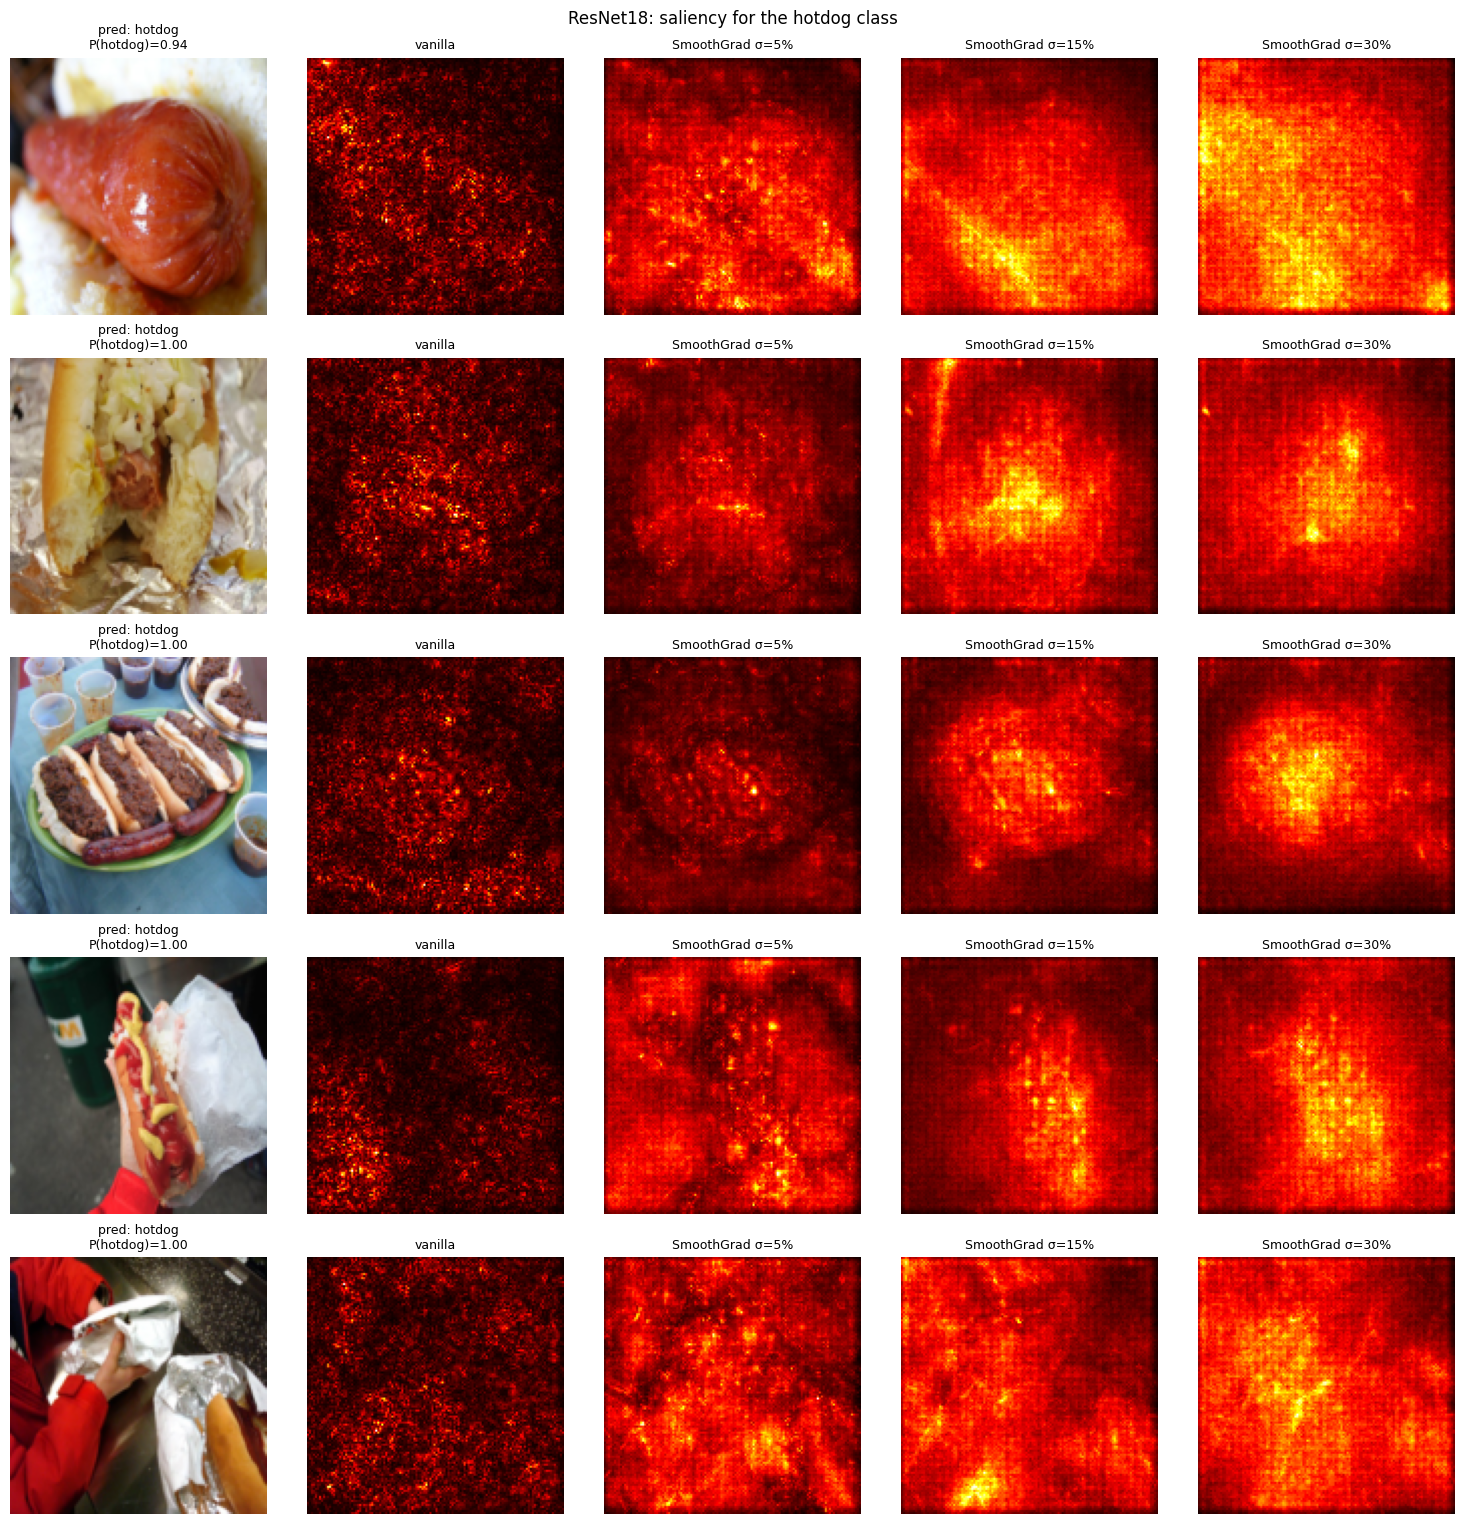

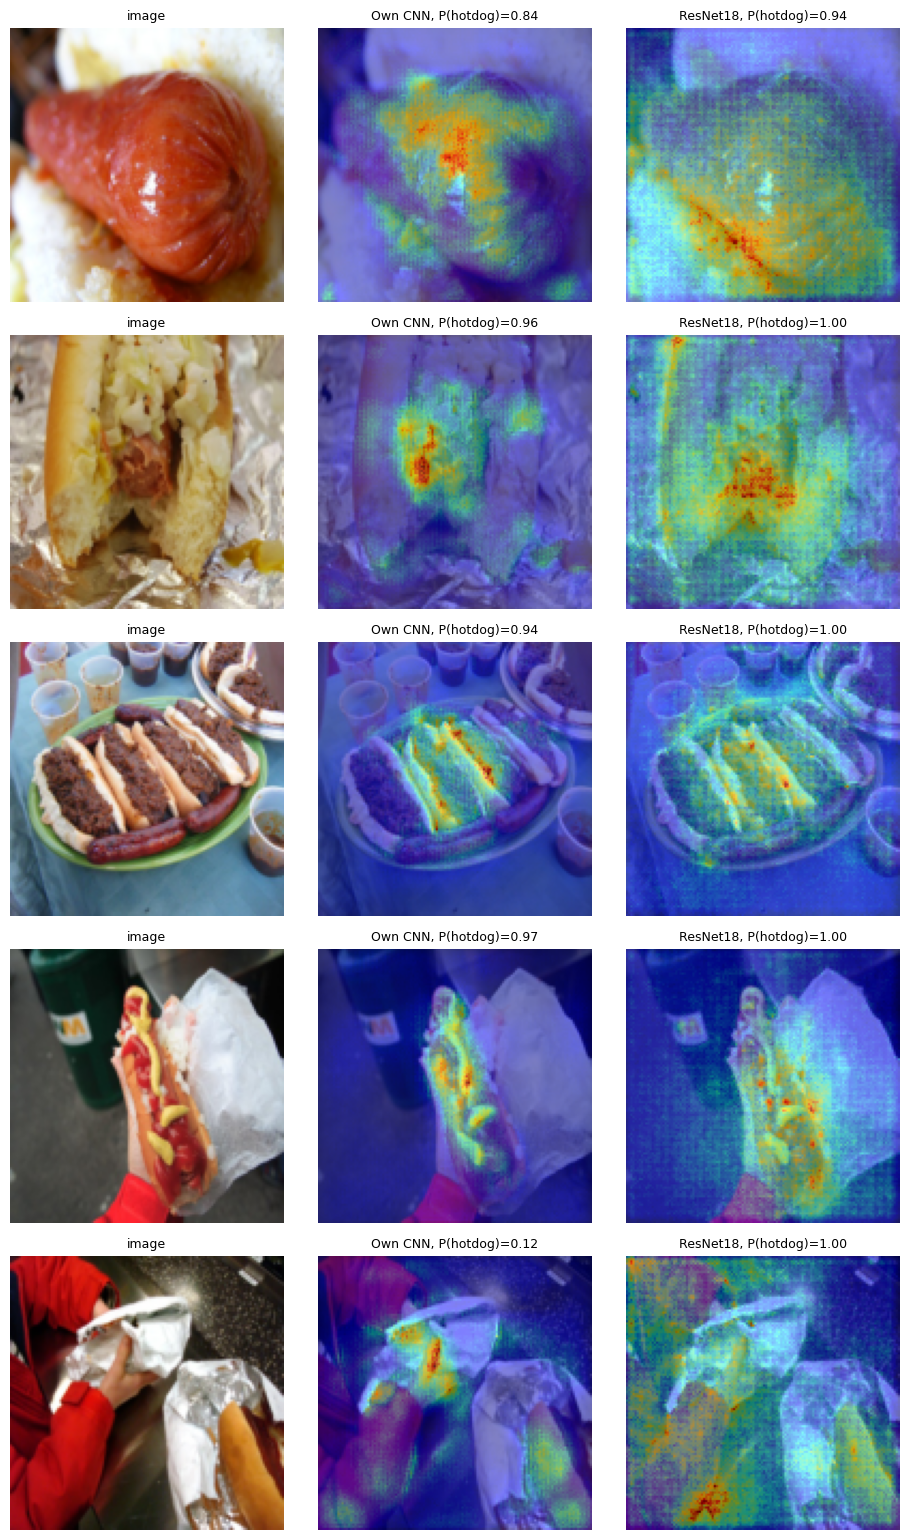

In [16]:
saliency_grid(resnet_model, resnet_results, 'ResNet18', 'saliency_resnet18.png')

# Sammenligning: SmoothGrad (sigma = 15 %) lagt oven på billedet for begge modeller
plt.figure(figsize=(9.5, 3.1 * len(chosen)))
for row, i in enumerate(chosen):
    x = testset[i][0].unsqueeze(0)
    img = x[0].permute(1, 2, 0).numpy()
    panels = [(None, 'image'),
              (smoothgrad(cnn_model, x), f"Own CNN, P(hotdog)={1 - cnn_results['probs'][i]:.2f}"),
              (smoothgrad(resnet_model, x), f"ResNet18, P(hotdog)={1 - resnet_results['probs'][i]:.2f}")]
    for c, (m, title) in enumerate(panels):
        plt.subplot(len(chosen), 3, row * 3 + c + 1)
        plt.imshow(img)
        if m is not None:
            plt.imshow((m / (m.max() + 1e-12)).numpy(), cmap='jet', alpha=0.5)
        plt.title(title, fontsize=9)
        plt.axis('off')
plt.tight_layout()
plt.savefig('saliency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()